
# Bipartite Kuramoto Clustering — `script.ipynb`

Pipeline por **bloques** para clustering con **Kuramoto bipartito**:
1) Matriz N×M (aleatoria o CSV local)  
2) Normalización [0,1]  
3) Multiplicar por 2π → fases Θ  
4) Promedios por fila/columna → fases iniciales  
5) Integración Kuramoto (RK4, ω=0, K uniforme)  
6) Afinidades (PLV): cruzada, intra-filas, intra-columnas  
7) Coherencia global y por partición, resumen y gráfico  

**Bloque extra:** clustering de **ELEMENTOS (i,j)** de `A_cross` para etiquetar coordenadas de la matriz original `X`.


In [1]:

# ==============================
# Configuración general
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Dimensiones (solo si USE_CSV=False)
N = 150
M = 100

# Rango enteros aleatorios (inclusivo)
RAND_MIN = 0
RAND_MAX = 100

# Semilla
SEED = 42

# Acoplamiento uniforme
K = 1.0

# Integración (RK4)
dt = 0.01
T_total = 5.0
NUM_STEPS = int(T_total / dt)

# Entrada por CSV (misma carpeta del notebook)
USE_CSV = True     # Cambiar a True para cargar CSV
CSV_NAME = None     # Si None, se detecta el primer .csv
CSV_DELIMITER = ","

# Guardado
SAVE_PREFIX = "kuramoto_bipartito"
SAVE_CSV = True
SAVE_PNG = True

np.random.seed(SEED)
print(f"Config -> N={N}, M={M}, RAND=[{RAND_MIN},{RAND_MAX}], K={K}, dt={dt}, T={T_total}s")


Config -> N=150, M=100, RAND=[0,100], K=1.0, dt=0.01, T=5.0s


In [2]:
# ==============================
# Cargar archivo CSV / OTUS desde ruta
# ==============================
import pandas as pd
import numpy as np
from pathlib import Path

# Ruta del archivo (TÚ LA DEFINES AQUÍ)
# Ejemplos válidos:
# FILE_PATH = r"D:\datos\otu_data.otus"
# FILE_PATH = "./data/tabla.csv"
# FILE_PATH = "/home/user/matrices/matriz.otus"

FILE_PATH = r"C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data.otus"   # <<< MODIFÍCALA AQUÍ


def load_matrix_from_path(path):
    """
    Carga una matriz numérica desde un archivo .csv o .otus.
    La ruta debe ser absoluta o relativa.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
    elif ext == ".otus":
        df = pd.read_csv(path, sep="\t")  # Formato típico OTU
    else:
        raise ValueError(f"Formato no soportado: {ext}. Usa .csv o .otus")

    # Mantener únicamente columnas numéricas
    df_numeric = df.select_dtypes(include=[np.number])

    if df_numeric.empty:
        raise ValueError(f"El archivo {path.name} no contiene columnas numéricas.")

    return df_numeric.values.astype(float)


# ==============================
# Carga de la matriz
# ==============================
X = load_matrix_from_path(FILE_PATH)
print(f"✅ Archivo cargado: {FILE_PATH} → matriz {X.shape}")


✅ Archivo cargado: C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data.otus → matriz (441, 4738)


Número total de valores: 2089458
Min: 0, Max: 6.071e+04


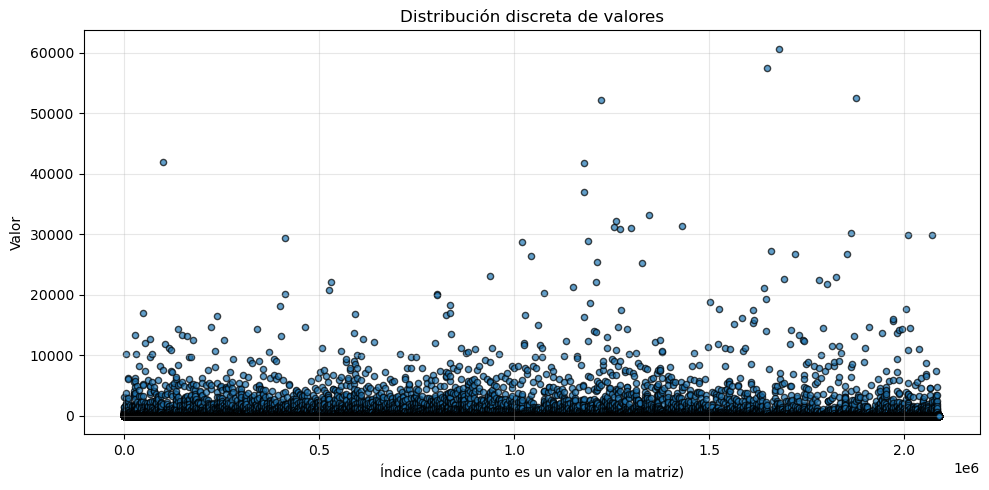

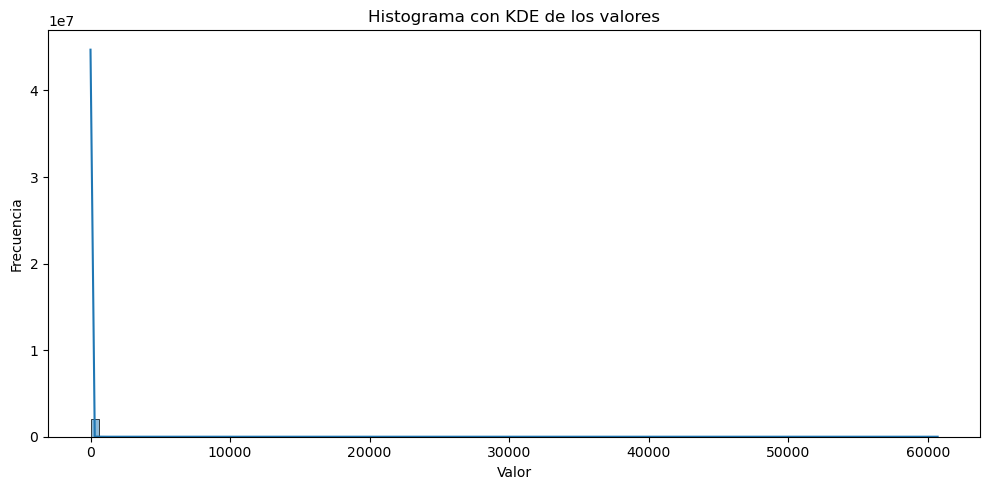

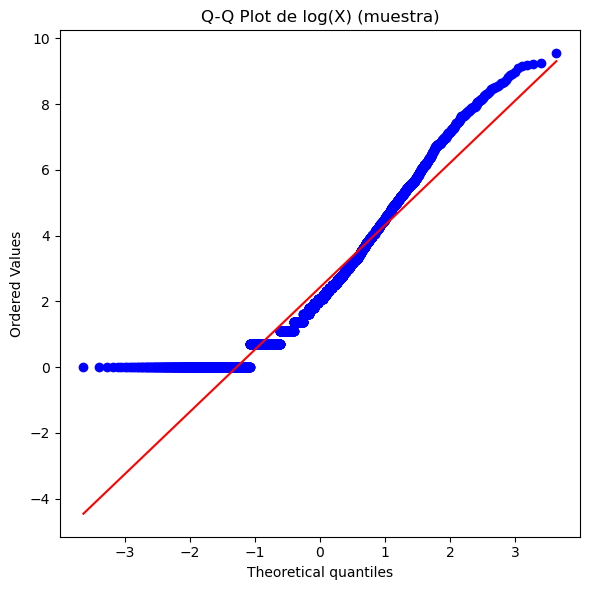

Prueba de normalidad Shapiro-Wilk sobre log(X):
  estadístico = 0.9287, p = 1.08e-43
  ➜ Se rechaza normalidad de log(X) → NO claramente lognormal.

AIC por distribución (menor es mejor):
  lognormal: AIC = 46,624.53
  expon    : AIC = 238,738.04
  normal   : AIC = 329,716.60
  gamma    : AIC = 1,570,786.29

➜ Distribución candidata con mejor AIC: lognormal


In [3]:
# =========================================
# Bloque: Análisis de distribución de X
# =========================================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, probplot, lognorm, gamma, expon, norm

# -----------------------------
# 0. Preparar datos
# -----------------------------
valores = X.flatten().astype(float)
indices = np.arange(len(valores))

print(f"Número total de valores: {len(valores)}")
print(f"Min: {valores.min():.4g}, Max: {valores.max():.4g}")

# -----------------------------
# 1. Gráfico discreto de puntos
# -----------------------------
plt.figure(figsize=(10, 5))
plt.scatter(indices, valores, s=20, alpha=0.7, edgecolor='black')
plt.title("Distribución discreta de valores")
plt.xlabel("Índice (cada punto es un valor en la matriz)")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Histograma + KDE
# -----------------------------
plt.figure(figsize=(10, 5))
sns.histplot(valores, bins=100, kde=True)
plt.title("Histograma con KDE de los valores")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Prueba de lognormalidad
#    (normalidad de log(X))
# -----------------------------
valores_pos = valores[valores > 0]

if len(valores_pos) == 0:
    print("⚠ No hay valores positivos, no se puede evaluar lognormalidad.")
else:
    # Muestra para Shapiro (limite típico ~5000)
    np.random.seed(42)
    sample_size = min(len(valores_pos), 5000)
    muestra = np.random.choice(valores_pos, size=sample_size, replace=False)
    log_vals = np.log(muestra)

    # 3.1 Q-Q plot de log(X)
    plt.figure(figsize=(6, 6))
    probplot(log_vals, dist="norm", plot=plt)
    plt.title("Q-Q Plot de log(X) (muestra)")
    plt.tight_layout()
    plt.show()

    # 3.2 Shapiro-Wilk sobre log(X)
    stat, p = shapiro(log_vals)
    print(f"Prueba de normalidad Shapiro-Wilk sobre log(X):")
    print(f"  estadístico = {stat:.4f}, p = {p:.4g}")
    if p > 0.05:
        print("  ➜ No se rechaza normalidad de log(X) → lognormalidad plausible.")
    else:
        print("  ➜ Se rechaza normalidad de log(X) → NO claramente lognormal.")

    # -----------------------------
    # 4. Comparar distribuciones con AIC
    # -----------------------------
    def aic(loglik, k):
        return 2 * k - 2 * loglik

    def log_likelihood(dist, data, force_pos=True):
        # Para distribuciones de soporte positivo (lognorm, gamma, expon)
        if force_pos:
            data = data[data > 0]
        params = dist.fit(data)
        ll = np.sum(dist.logpdf(data, *params))
        return ll, params

    candidatas = {
        "lognormal": (lognorm, True),
        "gamma":     (gamma, True),
        "expon":     (expon, True),
        "normal":    (norm, False),
    }

    # Usamos una muestra (para no morir con millones de datos)
    data_aic = valores_pos if len(valores_pos) <= 20000 else np.random.choice(valores_pos, size=20000, replace=False)

    aic_results = {}
    for nombre, (dist, pos_only) in candidatas.items():
        try:
            ll, params = log_likelihood(dist, data_aic, force_pos=pos_only)
            aic_val = aic(ll, len(params))
            aic_results[nombre] = (aic_val, params)
        except Exception as e:
            aic_results[nombre] = (np.inf, None)
            print(f"  ⚠ Error ajustando {nombre}: {e}")

    print("\nAIC por distribución (menor es mejor):")
    for nombre, (aic_val, params) in sorted(aic_results.items(), key=lambda x: x[1][0]):
        print(f"  {nombre:9s}: AIC = {aic_val:,.2f}")

    best = min(aic_results.items(), key=lambda x: x[1][0])[0]
    print(f"\n➜ Distribución candidata con mejor AIC: {best}")


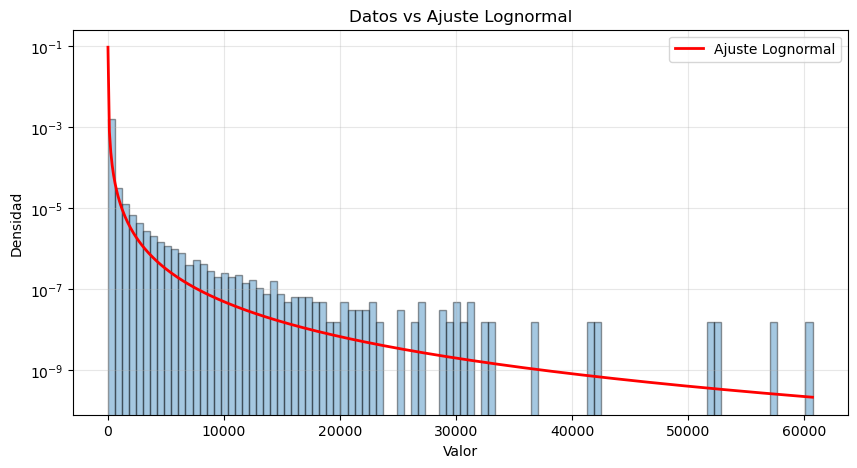

In [4]:
from scipy.stats import lognorm
import numpy as np
import matplotlib.pyplot as plt

# Datos positivos
val_pos = valores[valores > 0]

# Ajustar la lognormal
shape, loc, scale = lognorm.fit(val_pos, floc=0)

# Rango de X para graficar el modelo
x = np.linspace(val_pos.min(), val_pos.max(), 500)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

plt.figure(figsize=(10,5))

# Histograma normalizado
plt.hist(val_pos, bins=100, density=True, alpha=0.4, edgecolor='black')

# Curva ajustada
plt.plot(x, pdf, "r", lw=2, label="Ajuste Lognormal")

#plt.xscale("log")
plt.yscale("log")
plt.title("Datos vs Ajuste Lognormal")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [5]:

# ==============================
# Bloque 2: Normalización [0,1]
# ==============================
X_min = float(np.min(X))
X_max = float(np.max(X))
if X_max == X_min:
    X_norm = np.ones_like(X)
else:
    X_norm = (X - X_min) / (X_max - X_min)

print(f"Normalización: min={X_min:.6g}, max={X_max:.6g}")
print(f"Rango X_norm -> [{X_norm.min():.6f}, {X_norm.max():.6f}]")


Normalización: min=0, max=60711
Rango X_norm -> [0.000000, 1.000000]


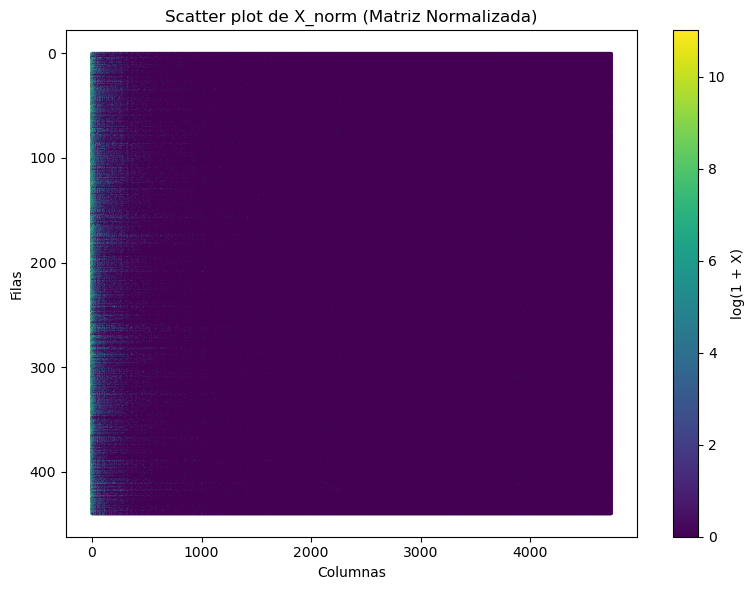

In [6]:
# ==============================
# Bloque 3: Gráfico de puntos (scatter) de X_norm
# ==============================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Si es vector 1D → puntos simples
if X_norm.ndim == 1:
    plt.scatter(np.arange(len(X_norm)), X_norm, s=25)
    plt.title("Scatter plot de X_norm (Vector Normalizado)")
    plt.xlabel("Índice")
    plt.ylabel("Valor Normalizado [0,1]")

# Si es matriz 2D → puntos por posición
elif X_norm.ndim == 2:
    filas, cols = X_norm.shape

    # Generar coordenadas de cada punto
    xs, ys = np.meshgrid(np.arange(cols), np.arange(filas))

    plt.scatter(xs.flatten(), ys.flatten(),
            c=np.log1p(X), cmap="viridis", s=1)

    plt.title("Scatter plot de X_norm (Matriz Normalizada)")
    plt.xlabel("Columnas")
    plt.ylabel("Filas")
    plt.gca().invert_yaxis()  # solo visual, opcional




else:
    raise ValueError("X_norm debe ser 1D o 2D.")

plt.colorbar(label="log(1 + X)")
plt.tight_layout()
plt.show()


In [7]:

# ==============================
# Bloque 3: Multiplicar por 2π
# ==============================
TWO_PI = 2.0 * np.pi
Theta = TWO_PI * X_norm   # fases base (N x M)
print("Theta lista. Ejemplo [0,0]:", float(Theta[0,0]))


Theta lista. Ejemplo [0,0]: 0.03663664902145531


In [8]:

# ==============================
# Bloque 4: Promedios por fila y columna (fases iniciales)
# ==============================
def wrap_2pi(angle):
    return np.mod(angle, TWO_PI)

phi0 = np.mean(Theta, axis=1)   # N,
psi0 = np.mean(Theta, axis=0)   # M,

phi0 = wrap_2pi(phi0)
psi0 = wrap_2pi(psi0)

print("Fases iniciales:")
print("phi0 (N) ->", phi0.shape, "  rango:[", float(phi0.min()), ",", float(phi0.max()), "]")
print("psi0 (M) ->", psi0.shape, "  rango:[", float(psi0.min()), ",", float(psi0.max()), "]")


Fases iniciales:
phi0 (N) -> (441,)   rango:[ 8.009922895407286e-05 , 0.002242428918577894 ]
psi0 (M) -> (4738,)   rango:[ 0.0 , 0.2769740428660858 ]


In [10]:

# ==============================
# Bloque 5: Kuramoto bipartito (RK4)
# ==============================
# dφ_i/dt = (K / M) * Σ_j W_ij * sin(ψ_j - φ_i)
# dψ_j/dt = (K / N) * Σ_i W_ij * sin(φ_i - ψ_j)
# ω = 0, W = X_norm (pre-2π)

W = X_norm.copy()

def kuramoto_rhs(phi, psi, W, K):
    Nr = phi.shape[0]
    Mc = psi.shape[0]
    phi_col = phi[:, None]   # N x 1
    psi_row = psi[None, :]   # 1 x M

    sin_term_rows = np.sin(psi_row - phi_col)  # N x M
    dphi = (K / max(1, Mc)) * np.sum(W * sin_term_rows, axis=1)

    sin_term_cols = np.sin(phi_col - psi_row)  # N x M
    dpsi = (K / max(1, Nr)) * np.sum(W * sin_term_cols, axis=0)
    return dphi, dpsi

def rk4_step(phi, psi, dt, W, K):
    k1_phi, k1_psi = kuramoto_rhs(phi, psi, W, K)
    k2_phi, k2_psi = kuramoto_rhs(phi + 0.5 * dt * k1_phi, psi + 0.5 * dt * k1_psi, W, K)
    k3_phi, k3_psi = kuramoto_rhs(phi + 0.5 * dt * k2_phi, psi + 0.5 * dt * k2_psi, W, K)
    k4_phi, k4_psi = kuramoto_rhs(phi + dt * k3_phi, psi + dt * k3_psi, W, K)

    phi_next = phi + (dt / 6.0) * (k1_phi + 2*k2_phi + 2*k3_phi + k4_phi)
    psi_next = psi + (dt / 6.0) * (k1_psi + 2*k2_psi + 2*k3_psi + k4_psi)
    return np.mod(phi_next, TWO_PI), np.mod(psi_next, TWO_PI)

phi = phi0.copy()
psi = psi0.copy()

traj_phi = np.empty((NUM_STEPS, phi.size), dtype=float)
traj_psi = np.empty((NUM_STEPS, psi.size), dtype=float)

for t in range(NUM_STEPS):
    traj_phi[t, :] = phi
    traj_psi[t, :] = psi
    phi, psi = rk4_step(phi, psi, dt, W, K)

print(f"Integración completada: pasos={NUM_STEPS}, dt={dt}, T={T_total}s")


Integración completada: pasos=500, dt=0.01, T=5.0s


In [12]:

# ==============================
# Bloque 6: Matrices de afinidad (PLV)
# ==============================
def plv_matrices(traj_phi, traj_psi):
    Z_rows = np.exp(1j * traj_phi)  # T x N
    Z_cols = np.exp(1j * traj_psi)  # T x M
    Tsteps = traj_phi.shape[0]

    A_cross = np.abs((Z_rows.conj().T @ Z_cols) / Tsteps)  # N x M
    A_rows  = np.abs((Z_rows.conj().T @ Z_rows) / Tsteps)  # N x N
    A_cols  = np.abs((Z_cols.conj().T @ Z_cols) / Tsteps)  # M x M
    return A_cross, A_rows, A_cols

A_cross, A_rows, A_cols = plv_matrices(traj_phi, traj_psi)

print("Afinidades listas:")
print("A_cross (N x M):", A_cross.shape, "  rango:[", float(A_cross.min()), ",", float(A_cross.max()), "]")
print("A_rows  (N x N):", A_rows.shape)
print("A_cols  (M x M):", A_cols.shape)

if SAVE_CSV:
    pd.DataFrame(A_cross).to_csv(f"{SAVE_PREFIX}_A_cross.csv", index=False)
    pd.DataFrame(A_rows).to_csv(f"{SAVE_PREFIX}_A_rows.csv", index=False)
    pd.DataFrame(A_cols).to_csv(f"{SAVE_PREFIX}_A_cols.csv", index=False)
    print("Guardado CSV de afinidades.")


Afinidades listas:
A_cross (N x M): (441, 4738)   rango:[ 0.9998764943136392 , 0.9999999999998854 ]
A_rows  (N x N): (441, 441)
A_cols  (M x M): (4738, 4738)
Guardado CSV de afinidades.


,r_rows_mean,r_rows_final,r_cols_mean,r_cols_final,r_global_mean,r_global_final,N,M,K,dt,T_total
0,1.0,1.0,0.999969,0.999974,0.999972,0.999976,441,4738,1.0,0.01,5.0


Guardado: kuramoto_bipartito_coherence_summary.csv


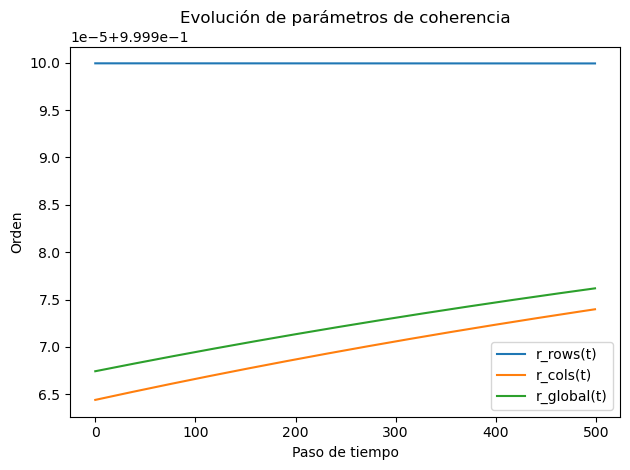

In [13]:

# ==============================
# Bloque 7: Parámetros de coherencia
# ==============================
def order_parameter(phases):
    Z = np.exp(1j * phases)        # T x K
    r_t = np.abs(np.mean(Z, axis=1))
    return r_t

r_rows = order_parameter(traj_phi)
r_cols = order_parameter(traj_psi)
phases_global = np.concatenate([traj_phi, traj_psi], axis=1)  # T x (N+M)
r_global = order_parameter(phases_global)

summary = {
    "r_rows_mean": float(np.mean(r_rows)),
    "r_rows_final": float(r_rows[-1]),
    "r_cols_mean": float(np.mean(r_cols)),
    "r_cols_final": float(r_cols[-1]),
    "r_global_mean": float(np.mean(r_global)),
    "r_global_final": float(r_global[-1]),
    "N": int(traj_phi.shape[1]),
    "M": int(traj_psi.shape[1]),
    "K": float(K),
    "dt": float(dt),
    "T_total": float(T_total)
}
summary_df = pd.DataFrame([summary])
display(summary_df)

if SAVE_CSV:
    summary_df.to_csv(f"{SAVE_PREFIX}_coherence_summary.csv", index=False)
    print("Guardado:", f"{SAVE_PREFIX}_coherence_summary.csv")

# Gráfico (una sola figura; sin estilos/colores específicos)
plt.figure()
plt.plot(r_rows, label="r_rows(t)")
plt.plot(r_cols, label="r_cols(t)")
plt.plot(r_global, label="r_global(t)")
plt.xlabel("Paso de tiempo")
plt.ylabel("Orden")
plt.title("Evolución de parámetros de coherencia")
plt.legend()
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(f"{SAVE_PREFIX}_coherence.png", dpi=160)
plt.show()


,K_embed,C_elem,db_index,inertia,sv_energy
0,1,2,0.754612,19824.913375,1.0
1,1,3,0.335540,2633.861795,1.0
2,1,4,0.389658,1443.751203,1.0
3,1,5,0.451743,878.267728,1.0
4,1,6,0.461381,696.163598,1.0


Guardado: kuramoto_bipartito_grid_scores.csv
Sugerencia óptima -> K_EMBED = 1 , N_ELEM_CLUSTERS = 3 , DB = 0.3355 , energía SVD = 1.0


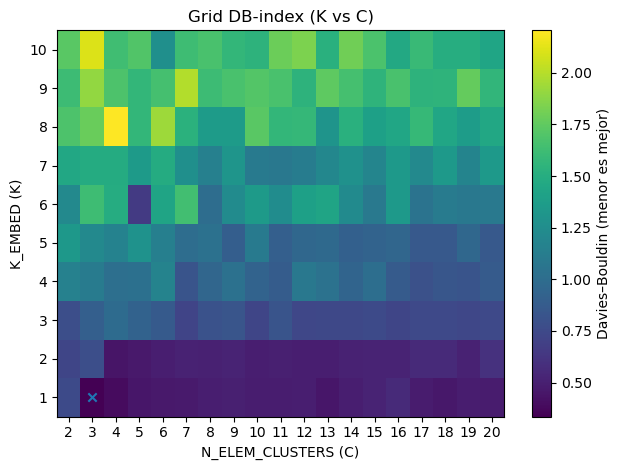

Figura guardada: kuramoto_bipartito_grid_dbindex.png


In [14]:
# === Selección automática de K_EMBED y N_ELEM_CLUSTERS por rejilla ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def standardized_features_from_UV_A(U_k, V_k, A):
    N, k1 = U_k.shape
    M, k2 = V_k.shape
    assert k1 == k2
    kk = k1
    feats = np.empty((N*M, 2*kk + 1), dtype=float)
    idx = 0
    for i in range(N):
        for j in range(M):
            feats[idx, :kk]      = U_k[i]
            feats[idx, kk:2*kk]  = V_k[j]
            feats[idx, -1]       = A[i, j]
            idx += 1
    mu = feats.mean(axis=0, keepdims=True)
    sigma = feats.std(axis=0, keepdims=True) + 1e-12
    return (feats - mu) / sigma

def kmeans_repeat(X, n_clusters, n_init=5, max_iter=60, random_state=0):
    rng = np.random.default_rng(random_state)
    best_labels = None
    best_centroids = None
    best_inertia = np.inf
    n_samples = X.shape[0]
    for _ in range(n_init):
        C = min(n_clusters, n_samples)
        centroids = X[rng.choice(n_samples, size=C, replace=False)]
        labels = np.zeros(n_samples, dtype=int)
        for _it in range(max_iter):
            d2 = ((X[:, None, :] - centroids[None, :, :])**2).sum(axis=2)
            new_labels = d2.argmin(axis=1)
            if np.array_equal(new_labels, labels):
                break
            labels = new_labels
            new_centroids = np.vstack([X[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
                                       for c in range(C)])
            if np.allclose(new_centroids, centroids, atol=1e-6):
                centroids = new_centroids
                break
            centroids = new_centroids
        inertia = 0.0
        for c in range(n_clusters):
            m = (labels == c)
            if not np.any(m): 
                continue
            dif = X[m] - centroids[c]
            inertia += float((dif*dif).sum())
        if inertia < best_inertia:
            best_inertia  = inertia
            best_labels   = labels.copy()
            best_centroids= centroids.copy()
    return best_labels, best_centroids, best_inertia

def davies_bouldin_index(X, labels, centroids):
    C = centroids.shape[0]
    if C <= 1:
        return np.inf
    # dispersión intra
    S = np.zeros(C, dtype=float)
    for i in range(C):
        m = (labels == i)
        if not np.any(m):
            S[i] = 0.0
        else:
            dif = X[m] - centroids[i]
            S[i] = np.mean(np.sqrt((dif*dif).sum(axis=1)))
    # distancias entre centros
    M = np.sqrt(((centroids[:, None, :] - centroids[None, :, :])**2).sum(axis=2)) + 1e-12
    R = np.zeros((C, C), dtype=float)
    for i in range(C):
        for j in range(C):
            if i == j: 
                R[i, j] = -np.inf
            else:
                R[i, j] = (S[i] + S[j]) / M[i, j]
    return float(np.mean(R.max(axis=1)))

# --- SVD de la A_cross normalizada bipartita (recomendada para co-embeddings) ---
A = A_cross.astype(float)
N, M = A.shape
d_r = A.sum(axis=1); d_r[d_r==0] = 1e-12
d_c = A.sum(axis=0); d_c[d_c==0] = 1e-12
Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
sv2 = S**2
sv2_total = float(sv2.sum()) + 1e-12
cum_energy = np.cumsum(sv2) / sv2_total

# --- Rejilla ---
Kmax = min(min(N, M), 10)          # k hasta 10 o hasta rank
K_list = list(range(1, Kmax+1))
Cmax  = min(max(2, int(np.ceil(np.sqrt(N*M)))), 20)  # clusters de elementos hasta 20
C_list = list(range(2, Cmax+1))

# Para evitar costos altos, muestrear si hay demasiados elementos (pares i,j)
sample_cap = 8000
rng = np.random.default_rng(0)

results = []
best = None

def is_pref(r):  # preferimos K con energía SVD suficiente
    return r["sv_energy"] >= 0.85

for k in K_list:
    U_k = U[:, :k]
    V_k = VT[:k, :].T
    Xf = standardized_features_from_UV_A(U_k, V_k, A)
    if Xf.shape[0] > sample_cap:
        idx = rng.choice(Xf.shape[0], size=sample_cap, replace=False)
        X_eval = Xf[idx]
    else:
        X_eval = Xf

    for C in C_list:
        labels, centroids, inertia = kmeans_repeat(X_eval, n_clusters=C, n_init=5, max_iter=60, random_state=42)
        db = davies_bouldin_index(X_eval, labels, centroids)
        rec = {
            "K_embed": k,
            "C_elem": C,
            "db_index": db,
            "inertia": inertia,
            "sv_energy": float(cum_energy[k-1])
        }
        results.append(rec)

        if best is None:
            best = rec
        else:
            a, b = best, rec
            if is_pref(a) and not is_pref(b):
                pass
            elif not is_pref(a) and is_pref(b):
                best = b
            else:
                if b["db_index"] < a["db_index"] - 1e-9:
                    best = b
                elif abs(b["db_index"] - a["db_index"]) <= 1e-9 and b["inertia"] < a["inertia"] - 1e-9:
                    best = b

scores_df = pd.DataFrame(results)
display(scores_df.head())
scores_df.to_csv(f"{SAVE_PREFIX}_grid_scores.csv", index=False)
print("Guardado:", f"{SAVE_PREFIX}_grid_scores.csv")
print("Sugerencia óptima -> K_EMBED =", best["K_embed"], 
      ", N_ELEM_CLUSTERS =", best["C_elem"],
      ", DB =", round(best["db_index"],4), 
      ", energía SVD =", round(best["sv_energy"],3))

# Heatmap DB-index (K vs C)
pivot = scores_df.pivot(index="K_embed", columns="C_elem", values="db_index")
plt.figure()
im = plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.xticks(range(pivot.shape[1]), pivot.columns)
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.colorbar(im, label="Davies–Bouldin (menor es mejor)")
plt.xlabel("N_ELEM_CLUSTERS (C)")
plt.ylabel("K_EMBED (K)")
plt.title("Grid DB-index (K vs C)")
# marca el mejor
try:
    bi = K_list.index(best["K_embed"])
    bj = C_list.index(best["C_elem"])
    plt.scatter([bj], [bi], marker="x")
except Exception:
    pass
plt.tight_layout()
plt.savefig(f"{SAVE_PREFIX}_grid_dbindex.png", dpi=160)
plt.show()
print("Figura guardada:", f"{SAVE_PREFIX}_grid_dbindex.png")



## Bloque extra: **Clustering de ELEMENTOS** de `A_cross`

Agrupa cada **par (i,j)** (elemento de la matriz cruzada) usando un embedding bipartito (SVD de la afinidad normalizada) y **k-means** sobre el vector concatenado \([U_k(i,:), V_k(j,:), A_{ij}]\).
Genera:
- Gráfico de tamaños de grupos
- CSV `kuramoto_bipartito_element_clusters.csv` con columnas: `row_i, col_j, cluster, X_value, A_cross_value`
- Impresión de listas por cluster: `(i,j) -> X[i,j], A_cross[i,j]`


Usando selección óptima -> K_EMBED = 1 , N_ELEM_CLUSTERS = 3


,row_i,col_j,cluster,X_value,A_cross_value
0,0,0,2,354.0,1.000000
1,0,1,1,817.0,0.999866
2,0,2,2,50.0,0.999997
3,0,3,1,31.0,0.999848
4,0,4,2,448.0,1.000000


Guardado: kuramoto_bipartito_element_clusters.csv
Tamaños por cluster:
cluster
0      23675
1     143545
2    1922238
Name: count, dtype: int64


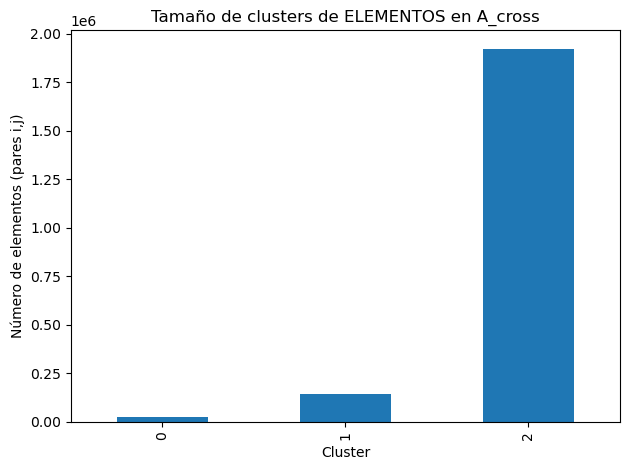

\nCluster 0 (n=23675):
 (i=249.0, j=0.0) -> X=2732, A_cross=1.0000
 (i=249.0, j=1.0) -> X=4.186e+04, A_cross=0.9999
 (i=249.0, j=2.0) -> X=1384, A_cross=1.0000
 (i=249.0, j=4.0) -> X=92, A_cross=1.0000
 (i=249.0, j=6.0) -> X=89, A_cross=1.0000
 (i=249.0, j=7.0) -> X=17, A_cross=1.0000
 (i=249.0, j=8.0) -> X=1.634e+04, A_cross=1.0000
 (i=249.0, j=9.0) -> X=1, A_cross=1.0000
 (i=249.0, j=10.0) -> X=0, A_cross=1.0000
 (i=249.0, j=11.0) -> X=2, A_cross=1.0000
 (i=249.0, j=12.0) -> X=0, A_cross=1.0000
 (i=249.0, j=13.0) -> X=9, A_cross=1.0000
 (i=249.0, j=14.0) -> X=1, A_cross=1.0000
 (i=249.0, j=15.0) -> X=47, A_cross=1.0000
 (i=249.0, j=16.0) -> X=280, A_cross=1.0000
 (i=249.0, j=17.0) -> X=47, A_cross=1.0000
 (i=249.0, j=18.0) -> X=260, A_cross=1.0000
 (i=249.0, j=19.0) -> X=10, A_cross=1.0000
 (i=249.0, j=20.0) -> X=17, A_cross=1.0000
 (i=249.0, j=21.0) -> X=39, A_cross=1.0000
 (i=249.0, j=22.0) -> X=2, A_cross=1.0000
 (i=249.0, j=23.0) -> X=229, A_cross=1.0000
 (i=249.0, j=24.0) -> X=4

In [14]:

# ==============================
# Clustering de ELEMENTOS (i,j) de A_cross
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def element_pair_clustering(A_nm, X_original, n_elem_clusters=6, k_embed=6, random_state=0, max_iter=60):
    A = np.asarray(A_nm, dtype=float)
    N, M = A.shape

    # --- Normalización bipartita D_r^{-1/2} A D_c^{-1/2}
    d_r = A.sum(axis=1); d_r[d_r==0] = 1e-12
    d_c = A.sum(axis=0); d_c[d_c==0] = 1e-12
    Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
    Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
    A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

    # --- SVD truncada
    U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
    kk = int(min(k_embed, U.shape[1], VT.shape[0]))
    if kk < 1:
        kk = 1
    U_k = U[:, :kk]      # N x kk
    V_k = VT[:kk, :].T   # M x kk

    # --- Construir features por elemento (i,j): [U_k(i,:), V_k(j,:), A_ij]
    feats = np.empty((N*M, 2*kk + 1), dtype=float)
    coords = np.empty((N*M, 2), dtype=int)
    idx = 0
    for i in range(N):
        for j in range(M):
            feats[idx, :kk] = U_k[i, :]
            feats[idx, kk:2*kk] = V_k[j, :]
            feats[idx, -1] = A[i, j]  # valor de afinidad
            coords[idx, 0] = i
            coords[idx, 1] = j
            idx += 1

    # --- Estandarizar features
    mu = feats.mean(axis=0, keepdims=True)
    sigma = feats.std(axis=0, keepdims=True) + 1e-12
    Xf = (feats - mu) / sigma

    # --- k-means minimalista
    rng = np.random.default_rng(random_state)
    C = min(n_elem_clusters, Xf.shape[0])
    centroids = Xf[rng.choice(Xf.shape[0], size=C, replace=False)]
    labels = np.zeros(Xf.shape[0], dtype=int)

    for _ in range(max_iter):
        d2 = ((Xf[:, None, :] - centroids[None, :, :])**2).sum(axis=2)  # (NM) x C
        new_labels = d2.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        new_centroids = np.vstack([Xf[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
                                   for c in range(C)])
        if np.allclose(new_centroids, centroids, atol=1e-6):
            centroids = new_centroids
            break
        centroids = new_centroids

    # --- Construir DataFrame de salida
    out = []
    for idx, (i, j) in enumerate(coords):
        out.append({
            "row_i": int(i),
            "col_j": int(j),
            "cluster": int(labels[idx]),
            "X_value": float(X_original[i, j]) if (i < X_original.shape[0] and j < X_original.shape[1]) else np.nan,
            "A_cross_value": float(A[i, j]),
        })
    df = pd.DataFrame(out)
    return df

# Parámetros del usuario (ajustables)
N_ELEM_CLUSTERS = int(best["C_elem"])
K_EMBED         = int(best["K_embed"])
RANDOM_STATE    = 0
print("Usando selección óptima ->",
      "K_EMBED =", K_EMBED, ", N_ELEM_CLUSTERS =", N_ELEM_CLUSTERS)


# Ejecutar clustering de elementos sobre A_cross
df_elems = element_pair_clustering(A_cross, X, n_elem_clusters=N_ELEM_CLUSTERS, k_embed=K_EMBED, random_state=RANDOM_STATE)
display(df_elems.head())

# Guardar CSV
csv_path = f"{SAVE_PREFIX}_element_clusters.csv"
df_elems.to_csv(csv_path, index=False)
print("Guardado:", csv_path)

# Resumen de tamaños por cluster
sizes = df_elems["cluster"].value_counts().sort_index()
print("Tamaños por cluster:")
print(sizes)

# Gráfico: barras de tamaños
plt.figure()
sizes.sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Número de elementos (pares i,j)")
plt.title("Tamaño de clusters de ELEMENTOS en A_cross")
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(f"{SAVE_PREFIX}_element_cluster_sizes.png", dpi=160)
plt.show()

# Listado por cluster (coordenadas y valores)
max_per_cluster_to_print = 50  # por si NM es grande
for c in sorted(df_elems["cluster"].unique()):
    sub = df_elems[df_elems["cluster"]==c]
    print(f"\\nCluster {c} (n={len(sub)}):")
    for _, r in sub.head(max_per_cluster_to_print).iterrows():
        print(f" (i={r['row_i']}, j={r['col_j']}) -> X={r['X_value']:.4g}, A_cross={r['A_cross_value']:.4f}")
    if len(sub) > max_per_cluster_to_print:
        print(f" ... (+{len(sub)-max_per_cluster_to_print} más)")
